# Análisis exploratorio de datos espaciales (ESDA)

In [ ]:
#!pip install pandas geopandas matplotlib os

In [66]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os, glob

## Cargar datos tabla

In [76]:
tabla = glob.glob("*.xlsx")
tabla

['Tabla_suelos.xlsx']

In [77]:
# Cargar el archivo XLS en un DataFrame de pandas
df = pd.read_excel(tabla[0], sheet_name='Suelo')

## Convertir en datos geoespaciales

In [78]:
# Asegúrate de usar columna 'ESTE' y 'NORTE'
geom = gpd.points_from_xy(df['X'], df['Y'])
gdf_punto = gpd.GeoDataFrame(df, geometry=geom,crs="EPSG:32618")

## Análisis estadistico

El método describe devuelve información estadística de los datos del dataframe o de la serie (de hecho, este método devuelve un dataframe). Esta información incluye el número de muestras, el valor medio, la desviación estándar, el valor mínimo, máximo, la mediana y los valores correspondientes a los percentiles 25%, 50% y 75%.

In [79]:
columnas = ['Arena', 'Arcilla', 'Limo','Ph', 'MO', 'N', 'P_ppm', 'K_ppm']

In [80]:
# Dividir en datos
Variable_suelo = gdf_punto[columnas]
xy = gdf_punto[['X', 'Y']]

In [81]:
estadistica = Variable_suelo.describe()
estadistica

,Arena,Arcilla,Limo,Ph,MO,N,P_ppm,K_ppm
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,31.892857,26.785714,41.321429,4.229286,3.099286,0.155357,2.610000,90.592143
std,11.754713,3.083494,10.811700,0.236595,0.671604,0.034371,1.239639,4.229970
min,13.000000,20.000000,26.000000,3.810000,1.760000,0.090000,0.580000,80.640000
25%,22.500000,25.750000,32.500000,4.080000,2.587500,0.127500,1.877500,88.162500
50%,35.000000,28.000000,40.000000,4.195000,3.030000,0.150000,2.515000,90.365000
75%,42.250000,28.250000,51.250000,4.402500,3.622500,0.180000,3.055000,94.557500
max,50.000000,32.000000,61.000000,4.750000,4.130000,0.210000,6.620000,97.480000


In [82]:
# Calcular estadísticos adicionales: mediana, varianza y covarianza
median = Variable_suelo.median(numeric_only=True)
variance = Variable_suelo.var(numeric_only=True)
covariance = Variable_suelo.std(numeric_only=True) / Variable_suelo.mean(numeric_only=True)

In [83]:
median

,0
Arena,35.000
Arcilla,28.000
Limo,40.000
Ph,4.195
MO,3.030
N,0.150
P_ppm,2.515
K_ppm,90.365


In [84]:
# Unir resultados al resumen
estadistica.loc['median'] = median
estadistica.loc['var'] = variance
estadistica.loc['cv'] = covariance

In [85]:
from scipy.stats import skew, kurtosis

* Corregido o no corregido por sesgo muestral (bias correction)
  
bias=False: aplica corrección por sesgo muestral.
* Fisher: 3 = distribución normal
  
fisher=True: devuelve 0 para distribución normal (en lugar de 3).

In [86]:
skewness = Variable_suelo.apply(lambda x: skew(x, bias=True))
kurtosis = Variable_suelo.apply(lambda x: kurtosis(x, bias=True, fisher=False))

In [87]:
# Agregar al resumen estadístico
estadistica.loc['skewness'] = skewness
estadistica.loc['kurtosis'] = kurtosis

In [88]:
estadistica

,Arena,Arcilla,Limo,Ph,MO,N,P_ppm,K_ppm
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,31.892857,26.785714,41.321429,4.229286,3.099286,0.155357,2.610000,90.592143
std,11.754713,3.083494,10.811700,0.236595,0.671604,0.034371,1.239639,4.229970
min,13.000000,20.000000,26.000000,3.810000,1.760000,0.090000,0.580000,80.640000
25%,22.500000,25.750000,32.500000,4.080000,2.587500,0.127500,1.877500,88.162500
50%,35.000000,28.000000,40.000000,4.195000,3.030000,0.150000,2.515000,90.365000
75%,42.250000,28.250000,51.250000,4.402500,3.622500,0.180000,3.055000,94.557500
max,50.000000,32.000000,61.000000,4.750000,4.130000,0.210000,6.620000,97.480000
median,35.000000,28.000000,40.000000,4.195000,3.030000,0.150000,2.515000,90.365000
var,138.173280,9.507937,116.892857,0.055977,0.451051,0.001181,1.536704,17.892647


In [89]:
estadistica.to_excel('Datos_suelo_estadisticos.xlsx', index=True)

### Medidas de Tendencia Central

#### mean (media)
Es el promedio de los datos.

Útil para representar el valor típico si la distribución no está sesgada.

#### median (mediana)

Valor que divide a los datos en dos partes iguales.

Es más robusta que la media si hay valores extremos.

__Interpretación:__

* Si media ≈ mediana: distribución simétrica.

* Si media > mediana: distribución sesgada a la derecha (positiva).

* Si media < mediana: sesgada a la izquierda (negativa).

### Medidas de Dispersión

#### std (desviación estándar)

Mide cuánto varían los valores respecto a la media.

Valores altos = mayor dispersión (heterogeneidad).

#### variance
Es el cuadrado de la desviación estándar.

Más útil matemáticamente que para interpretación directa.

### Forma de la Distribución

#### skewness (asimetría)
Mide la simetría de la distribución.

| Valor | Interpretación                       |
| ----- | ------------------------------------ |
| 0     | Simétrica                            |
| > 0   | Sesgo positivo (cola a la derecha)   |
| < 0   | Sesgo negativo (cola a la izquierda) |


### kurtosis (curtosis, tipo Fisher)
Mide el "picor" o concentración de datos en el centro y las colas.

| Valor (Fisher) | Interpretación                                |
| -------------- | --------------------------------------------- |
| ≈ 0            | Normal                                        |
| > 0            | Leptocúrtica (más concentrada, colas pesadas) |
| < 0            | Platicúrtica (más plana, colas ligeras)       |


## Histograma datos espaciales

In [90]:
Variable_suelo.columns

Index(['Arena', 'Arcilla', 'Limo', 'Ph', 'MO', 'N', 'P_ppm', 'K_ppm'], dtype='object')

In [ ]:
!pip install seaborn

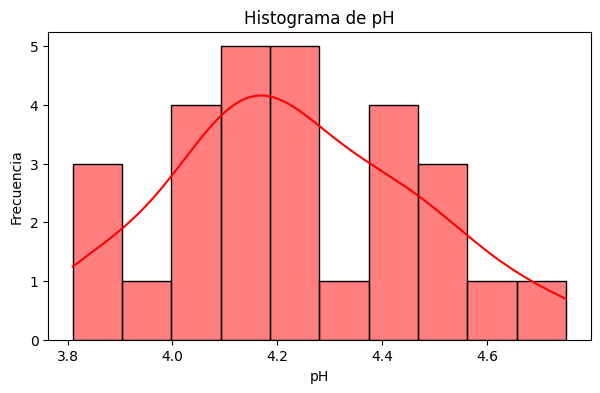

In [91]:
import seaborn as sns

plt.figure(figsize=(7,4))
sns.histplot(Variable_suelo['Ph'], kde=True, color='red', bins=10)
plt.title('Histograma de pH')
plt.xlabel('pH')
plt.ylabel('Frecuencia')
plt.show()

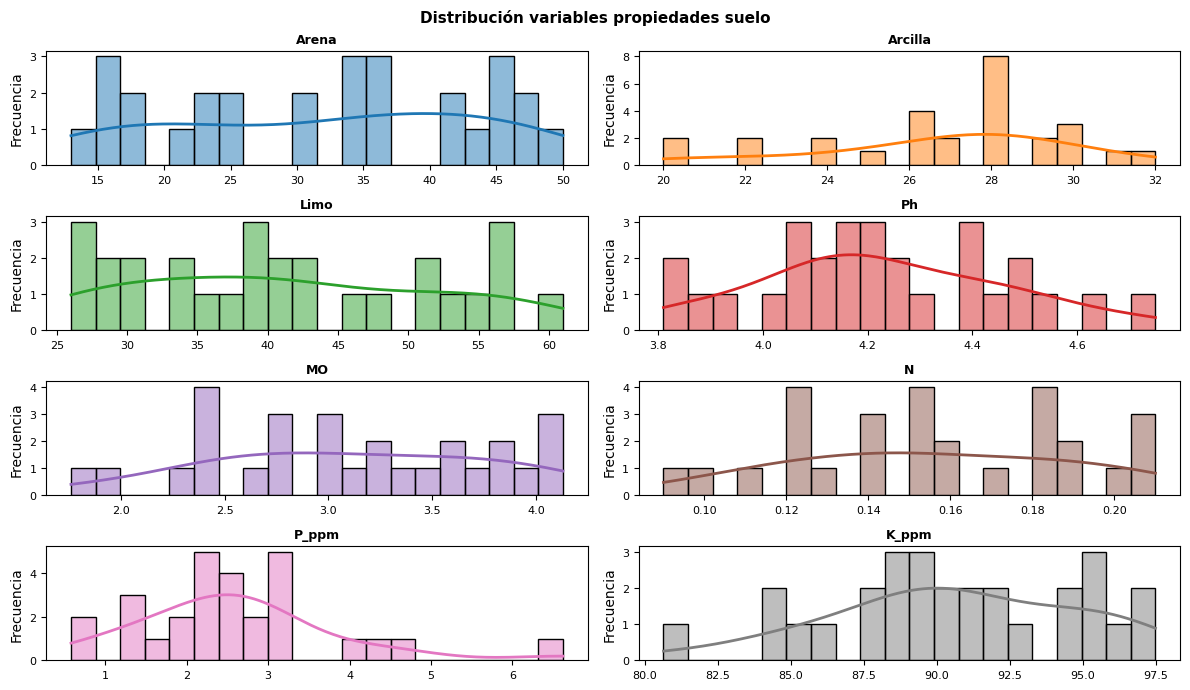

In [92]:
# Gráfico de distribución para cada variable numérica
# ==============================================================================
# Ajustar número de subplots en función del número de columnas
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 7))
axes = axes.flat
columnas_numeric = Variable_suelo.select_dtypes(include=['float64', 'int']).columns

for i, colum in enumerate(columnas_numeric):
    sns.histplot(
        data    = Variable_suelo,
        x       = colum,
        stat    = "count",
        kde     = True,
        color   = (list(plt.rcParams['axes.prop_cycle'])*2)[i]["color"],
        line_kws= {'linewidth': 2},
        bins = 20, # Más bins para mayor detalle
        alpha   = 0.5,
        ax      = axes[i]
    )
    axes[i].set_title(colum, fontsize = 9, fontweight = "bold")
    axes[i].tick_params(labelsize = 8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

# Eliminar los subplots no usados
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.subplots_adjust(top = 0.92)
fig.suptitle('Distribución variables propiedades suelo', fontsize = 11, fontweight = "bold");
plt.savefig("grafico_Histograma_suelo.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Gráfico Q-Q plot

El gráfico Q-Q (Quantile-Quantile) es útil para evaluar si los datos siguen una distribución normal.

* Si los puntos siguen una línea recta, la variable se distribuye aproximadamente normalmente.
* Curvas hacia abajo/arriba: indican colas pesadas o sesgo.
* Es muy útil para decidir si aplicar transformaciones logarítmicas, raíz cuadrada, etc.

In [93]:
import scipy.stats as stats

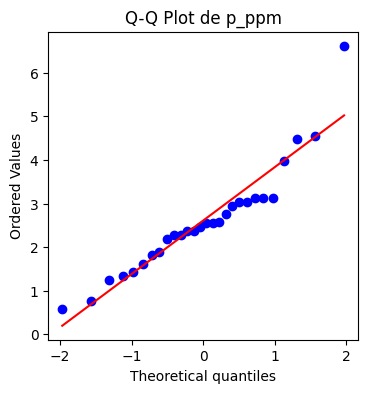

In [94]:
plt.figure(figsize=(4,4))
stats.probplot(Variable_suelo['P_ppm'], dist="norm", plot=plt)
plt.title('Q-Q Plot de p_ppm')
plt.show()

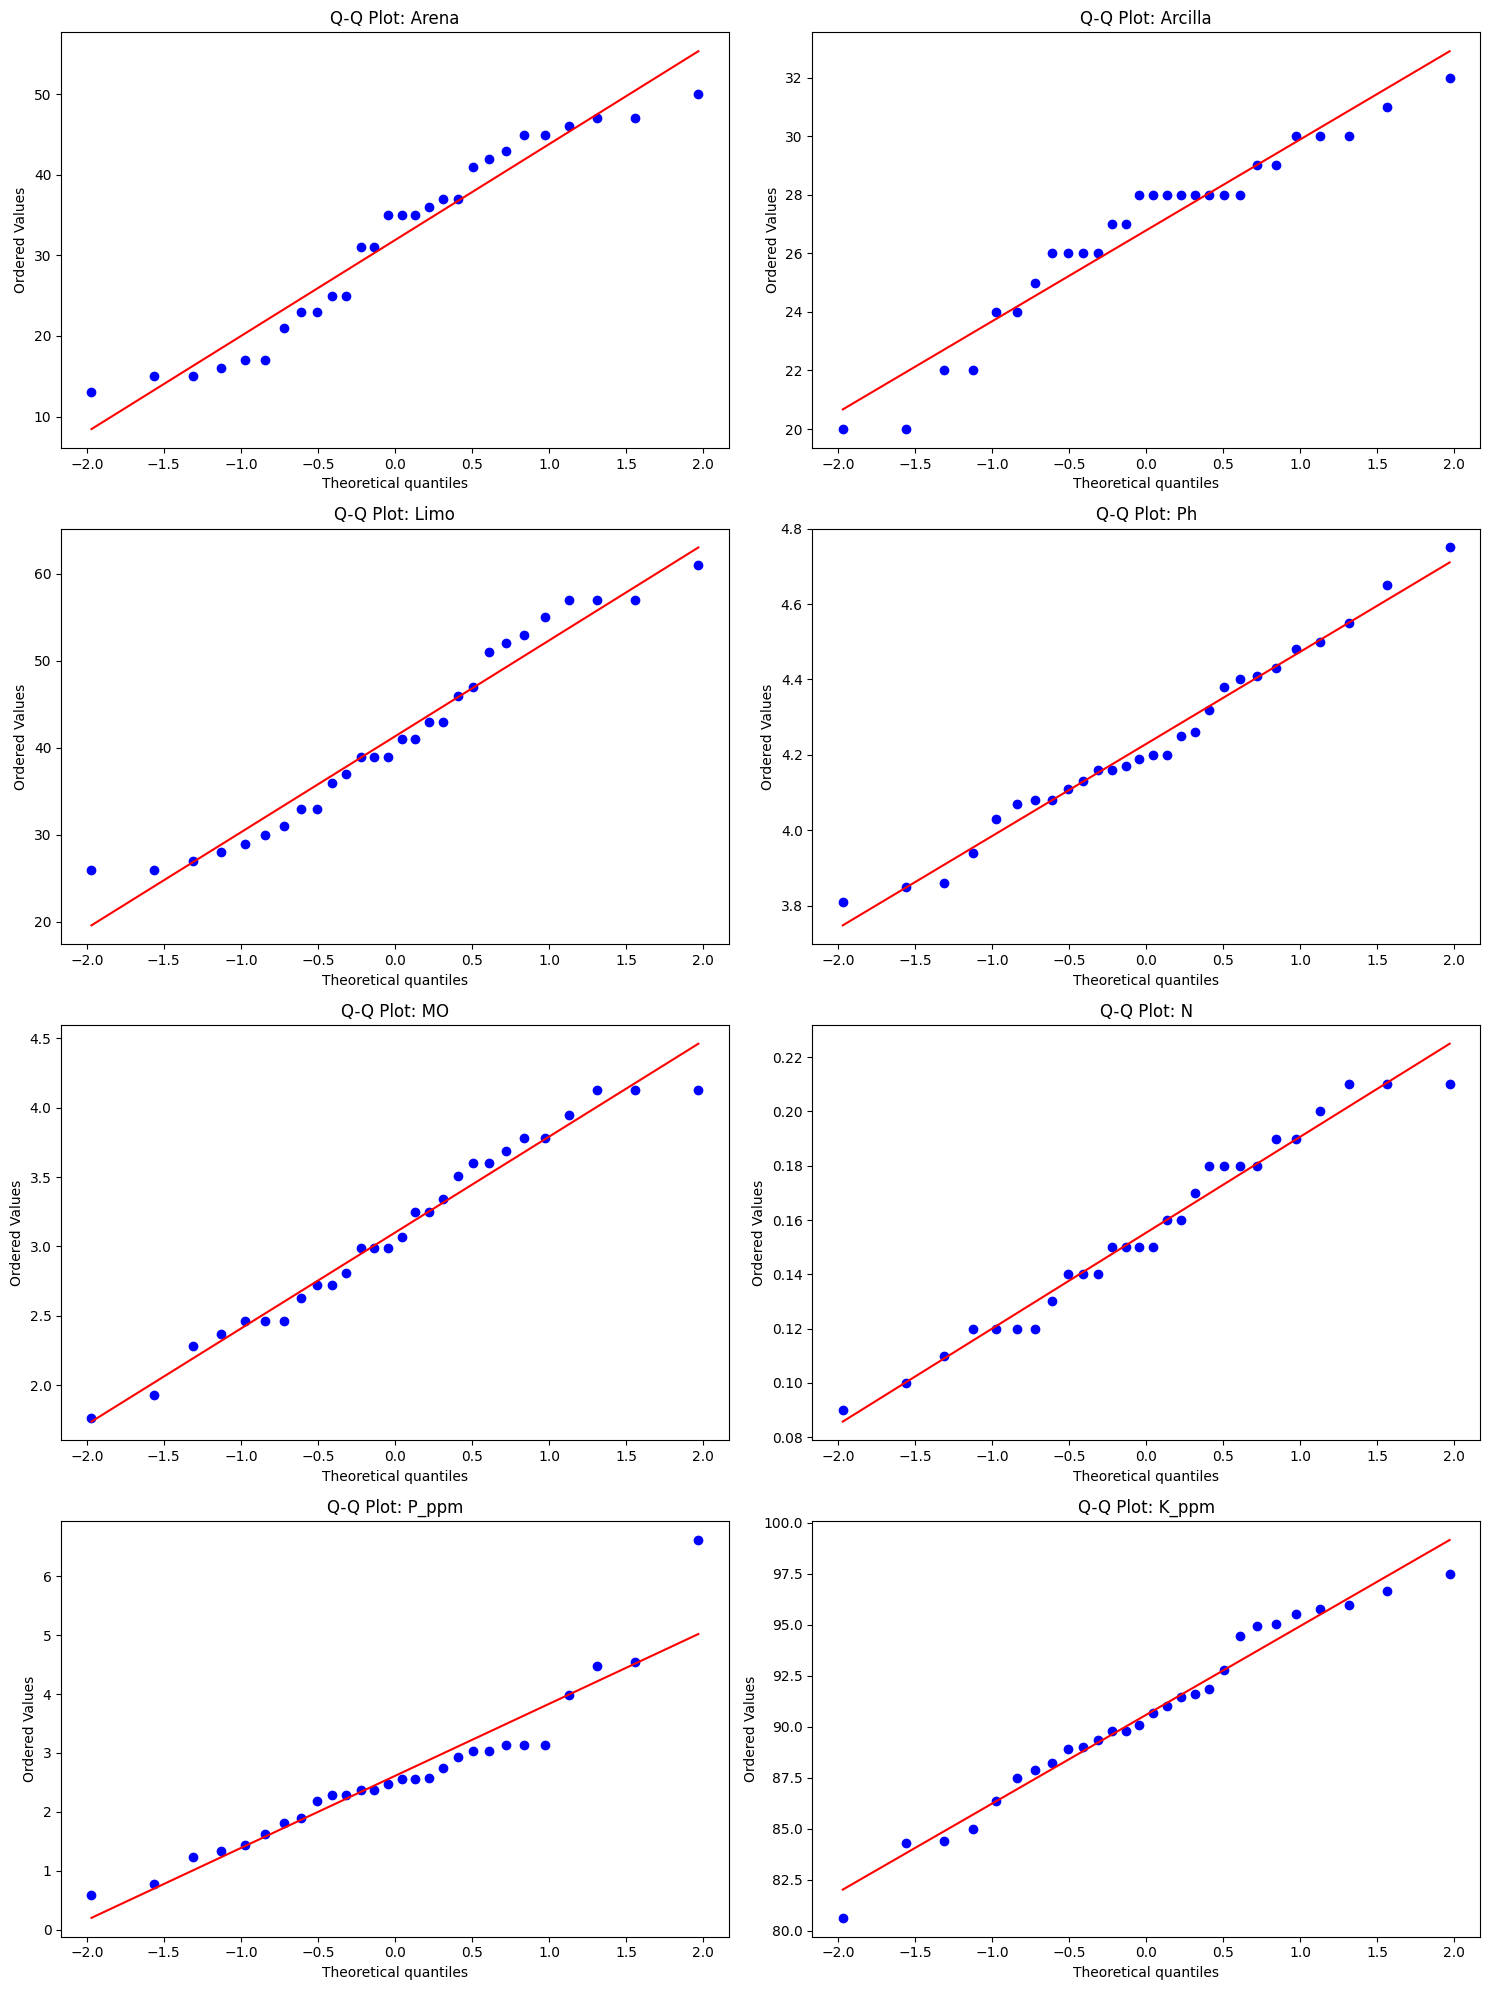

In [95]:
# Crear figura
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()
# Generar Q-Q plot para cada variable
for i, col in enumerate(columnas):
    stats.probplot(Variable_suelo[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {col}")
plt.tight_layout()
plt.show()

## Box plot

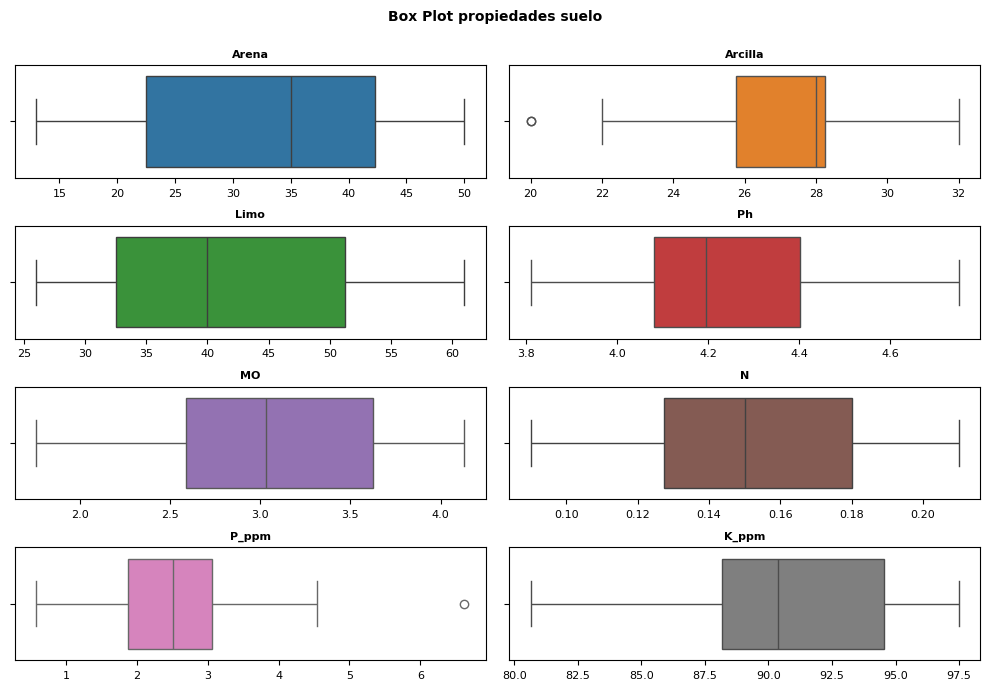

In [96]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 7))
axes = axes.flat
columnas_numeric = Variable_suelo.select_dtypes(include=['float64', 'int']).columns

for i, colum in enumerate(columnas_numeric):
    sns.boxplot(
        data    = Variable_suelo,
        x       = colum,
        color   = (list(plt.rcParams['axes.prop_cycle'])*2)[i]["color"],
        ax      = axes[i]
    )
    axes[i].set_title(colum, fontsize = 8, fontweight = "bold")
    axes[i].tick_params(labelsize = 8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Eliminar los subplots no usados
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.subplots_adjust(top = 0.9)
fig.suptitle('Box Plot propiedades suelo', fontsize = 10, fontweight = "bold");
plt.savefig("grafico_box_plot_propiedades_suelo.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Matriz de correlación variables

__¿Cómo interpretar la matriz?__

* Valores cercanos a +1 → correlación positiva fuerte (↑ una → ↑ la otra).

* Valores cercanos a -1 → correlación negativa fuerte (↑ una → ↓ la otra).

* Valores cercanos a 0 → poca o ninguna correlación lineal.

In [97]:
# Calcular matriz de correlación
correlation_matrix = Variable_suelo.corr()
print("Matriz de correlación:\n", correlation_matrix)

Matriz de correlación:
             Arena   Arcilla      Limo        Ph        MO         N     P_ppm  \
Arena    1.000000 -0.424719 -0.966092  0.519082  0.239115  0.253570 -0.329332   
Arcilla -0.424719  1.000000  0.176564 -0.129675 -0.002938 -0.013230  0.395135   
Limo    -0.966092  0.176564  1.000000 -0.527374 -0.259133 -0.271914  0.245364   
Ph       0.519082 -0.129675 -0.527374  1.000000  0.463443  0.486454 -0.199876   
MO       0.239115 -0.002938 -0.259133  0.463443  1.000000  0.996874  0.075369   
N        0.253570 -0.013230 -0.271914  0.486454  0.996874  1.000000  0.073192   
P_ppm   -0.329332  0.395135  0.245364 -0.199876  0.075369  0.073192  1.000000   
K_ppm   -0.010088 -0.112383  0.043020 -0.161489 -0.017451 -0.000235 -0.026388   

            K_ppm  
Arena   -0.010088  
Arcilla -0.112383  
Limo     0.043020  
Ph      -0.161489  
MO      -0.017451  
N       -0.000235  
P_ppm   -0.026388  
K_ppm    1.000000  


In [98]:
correlation_matrix.to_excel("Tabla_matrix_correlacion.xlsx")

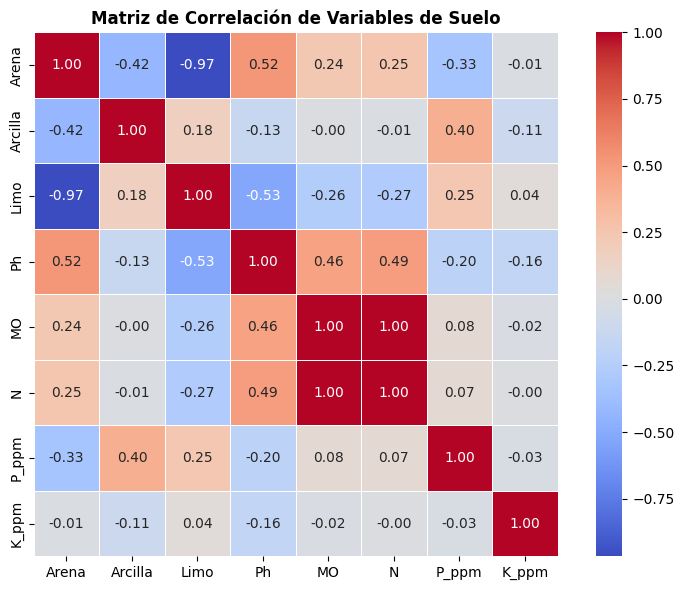

In [99]:
# Crear gráfico de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True)
plt.title("Matriz de Correlación de Variables de Suelo", fontsize = 12, fontweight = "bold")
plt.tight_layout()
plt.savefig("grafico_matrix_confunsion.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [100]:
os.getcwd()

'/content'

## Análisis de tendencia espacial

In [ ]:
!pip install statsmodels

In [101]:
import statsmodels.api as sm

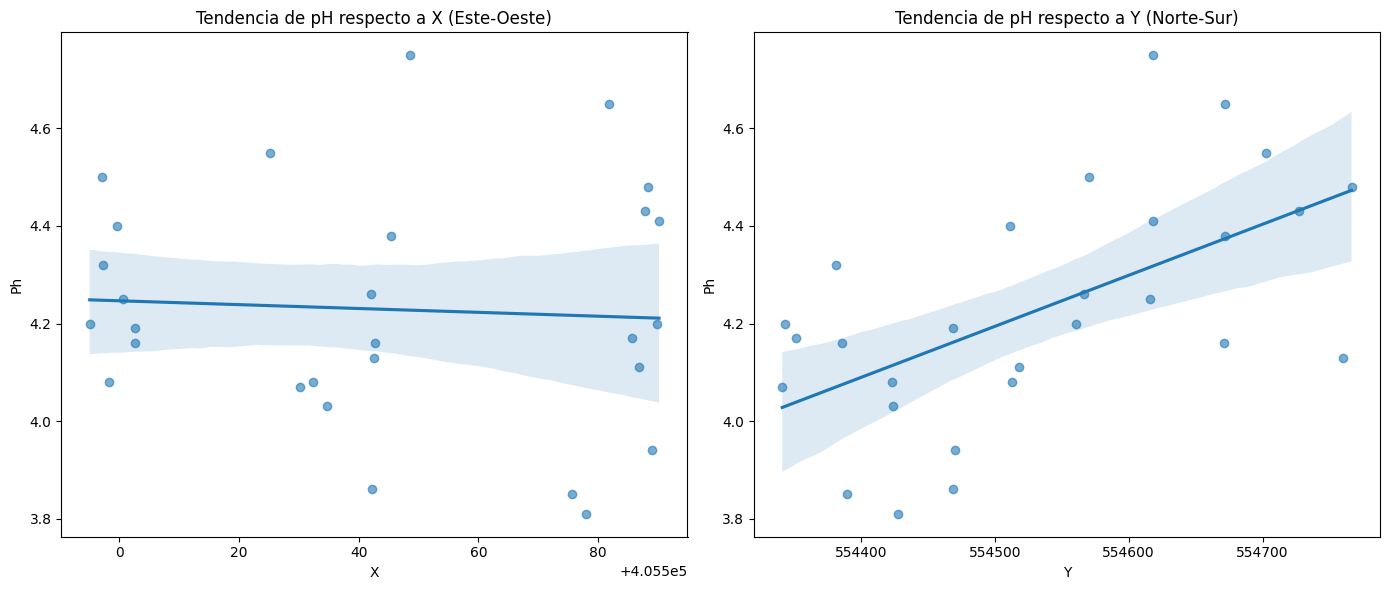

In [102]:
# Scatter plots con tendencia
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ph vs X
sns.regplot(data=gdf_punto, x="X", y="Ph", ax=axes[0], scatter_kws={'alpha':0.6})
axes[0].set_title("Tendencia de pH respecto a X (Este-Oeste)")

# Ph vs Y
sns.regplot(data=df, x="Y", y="Ph", ax=axes[1], scatter_kws={'alpha':0.6})
axes[1].set_title("Tendencia de pH respecto a Y (Norte-Sur)")

plt.tight_layout()
plt.show()

## Visualización 3D Predicción

In [103]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [104]:
gdf_punto.columns

Index(['fid', 'ID', 'Arena', 'Arcilla', 'Limo', 'Textura', 'Ph', 'MO', 'N',
       'P_ppm', 'K_ppm', 'CIC', 'Ca', 'Mg', 'AI', 'H', 'CICe', 'Bas_Camb',
       'Ac_Camb', 'Sat_AI', 'X', 'Y', 'geometry'],
      dtype='object')

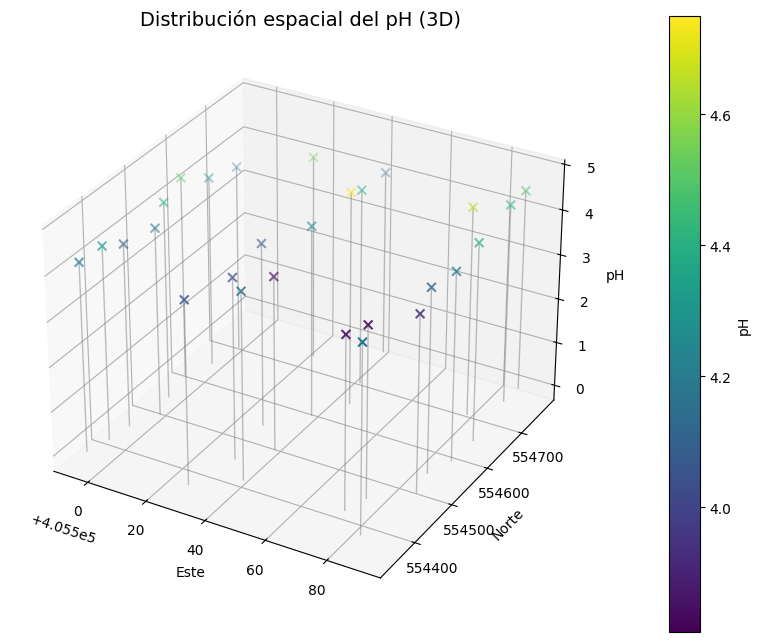

In [105]:
# Crear figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar puntos
sc = ax.scatter(gdf_punto["X"], gdf_punto["Y"], gdf_punto["Ph"],
                c=gdf_punto["Ph"], cmap='viridis', s=40, marker='x')

# Añadir líneas verticales desde el plano XY hasta el valor de pH
for i in range(len(gdf_punto)):
    ax.plot([gdf_punto["X"].iloc[i], gdf_punto["X"].iloc[i]],
            [gdf_punto["Y"].iloc[i], gdf_punto["Y"].iloc[i]],
            [0, gdf_punto["Ph"].iloc[i]],
            color='gray', alpha=0.5, linewidth=1)

# Etiquetas y título
ax.set_xlabel('Este')
ax.set_ylabel('Norte')
ax.set_zlabel('pH')
ax.set_title('Distribución espacial del pH (3D)', fontsize=14)

# Barra de color
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('pH')

plt.show()

## Generar una visualización interactiva en 3D

In [ ]:
import plotly.graph_objs as go
import plotly.io as pio

In [ ]:
x = gdf_punto["X"].values
y = gdf_punto["Y"].values
z = gdf_punto["Ph"].values

In [ ]:
# Scatter3D (marcador 'x')
scatter = go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(size=6,
                symbol='x',
                color=z,
                colorscale='RdYlGn',
                colorbar=dict(title='pH'),
                showscale=True),
    name='pH samples')

In [ ]:
# Líneas verticales: crear un trace por cada punto (o agrupar en un único trace con NaNs)
line_x = []
line_y = []
line_z = []
for xi, yi, zi in zip(x, y, z):
    line_x += [xi, xi, None]
    line_y += [yi, yi, None]
    line_z += [0, zi, None]

In [ ]:
lines = go.Scatter3d(x=line_x, y=line_y, z=line_z,
                     mode='lines',
                     line=dict(color='gray', width=2),
                     name='vertical lines')

In [ ]:
layout = go.Layout(title='Distribución espacial del pH (3D interactivo)',
                   scene=dict(xaxis=dict(title='Este (X)'),
                              yaxis=dict(title='Norte (Y)'),
                              zaxis=dict(title='pH'),),
                   margin=dict(l=0, r=0, b=0, t=40))

In [ ]:
fig = go.Figure(data=[scatter, lines], layout=layout)
# Guardar HTML interactivo
pio.write_html(fig, file="PH_3D_Interactive1.html", auto_open=True)
# También exportar un PNG estático por si quieres previsualizar rápido
try:
    pio.write_image(fig, "PH_3D_Interactiva1.png", width=1200, height=800, scale=2)
    png_created = True
except Exception as e:
    png_created = False


In [ ]:
os.getcwd()

'/content'

## Prueba de Normalidad

In [106]:
from scipy.stats import shapiro

In [107]:
# Generar resumen estadistica
summary_table = estadistica.T.copy()

In [108]:
# Prueba de normalidad (Shapiro-Wilk)
shapiro_results = Variable_suelo.apply(lambda x: shapiro(x)[1])  # Solo p-value
summary_table["p-value Shapiro"] = shapiro_results
summary_table["Normalidad (α=0.05)"] = summary_table["p-value Shapiro"].apply(
    lambda p: "Distribución normal" if p > 0.05 else "No distribución normal"
)

In [109]:
summary_table

,count,mean,std,min,25%,50%,75%,max,median,var,cv,skewness,kurtosis,p-value Shapiro,Normalidad (α=0.05)
Arena,28.0,31.892857,11.754713,13.00,22.5000,35.000,42.2500,50.00,35.000,138.173280,0.368569,-0.154050,1.666427,0.050769,Distribución normal
Arcilla,28.0,26.785714,3.083494,20.00,25.7500,28.000,28.2500,32.00,28.000,9.507937,0.115117,-0.698166,2.915491,0.066754,Distribución normal
Limo,28.0,41.321429,10.811700,26.00,32.5000,40.000,51.2500,61.00,40.000,116.892857,0.261649,0.221341,1.837205,0.118398,Distribución normal
Ph,28.0,4.229286,0.236595,3.81,4.0800,4.195,4.4025,4.75,4.195,0.055977,0.055942,0.234374,2.569829,0.815192,Distribución normal
MO,28.0,3.099286,0.671604,1.76,2.5875,3.030,3.6225,4.13,3.030,0.451051,0.216696,-0.110110,2.083835,0.455934,Distribución normal
N,28.0,0.155357,0.034371,0.09,0.1275,0.150,0.1800,0.21,0.150,0.001181,0.221237,-0.020367,2.031767,0.382411,Distribución normal
P_ppm,28.0,2.610000,1.239639,0.58,1.8775,2.515,3.0550,6.62,2.515,1.536704,0.474957,1.156377,5.309276,0.025171,No distribución normal
K_ppm,28.0,90.592143,4.229970,80.64,88.1625,90.365,94.5575,97.48,90.365,17.892647,0.046692,-0.291994,2.530865,0.596785,Distribución normal


## Transformación de datos a distribución normal

Estas serán transformadas con:

* log(x+1) (para evitar log(0)),

* sqrt(x) (raíz cuadrada).

### Transformación logarítmica

Aplicable a datos positivos para reducir la asimetría en la distribución. Si una variable contiene valores no positivos, se omite la transformación y se muestra una advertencia.

__Nota:__ Si has utilizando la transformación Box-Cox Lambda = 0, eso sería la transformación logarítmica.

### Transformación Box-Cox

Esta transformación se aplica a datos positivos y es útil para estabilizar la varianza y aproximar una distribución normal. Si una variable contiene valores no positivos, se omite la transformación y se muestra una advertencia.

In [110]:
# Filtrar solo las filas donde la normalidad es "No normal"
variables_no_normales = summary_table[summary_table["Normalidad (α=0.05)"] == "No distribución normal"].index.tolist()

In [111]:
variables_no_normales

['P_ppm']

In [112]:
# Valores de lambda a evaluar
lambda_values = [-2, -1, -0.5, 0, 0.5, 2]

In [113]:
# Copia del DataFrame para transformación
df_transformado = gdf_punto.copy()

In [114]:
# DataFrame para guardar resultados
resultados_boxcox = []

In [115]:
import numpy as np

In [116]:
# Aplicar para cada variable
for var in variables_no_normales:
    data = df[var]

    # Asegurar valores positivos (Box-Cox requiere x > 0)
    if (data <= 0).any():
        data = data + abs(data.min()) + 1

    for lmbda in lambda_values:
        if lmbda == 0:
            transformed = np.log(data)
        else:
            transformed = (data**lmbda - 1) / lmbda

        # Prueba de normalidad
        p_value = shapiro(transformed)[1]

        resultados_boxcox.append({
            'Variable': var,
            'Lambda': lmbda,
            'p-valor (Shapiro)': round(p_value, 5),
            '¿Normal (p > 0.05)?': 'Sí' if p_value > 0.05 else 'No',
            'Transformacion': f"boxcox_{lmbda}"
        })

In [117]:
# Convertir a DataFrame
df_resultados_boxcox = pd.DataFrame(resultados_boxcox)
df_resultados_boxcox

,Variable,Lambda,p-valor (Shapiro),¿Normal (p > 0.05)?,Transformacion
0,P_ppm,-2.0,0.00000,No,boxcox_-2
1,P_ppm,-1.0,0.00000,No,boxcox_-1
2,P_ppm,-0.5,0.00079,No,boxcox_-0.5
3,P_ppm,0.0,0.13164,Sí,boxcox_0
4,P_ppm,0.5,0.51176,Sí,boxcox_0.5
5,P_ppm,2.0,0.00000,No,boxcox_2


### Seleccion de Lambda

In [118]:
df_resultados_boxcox.to_excel("Seleccion_transformacion.xlsx")

In [ ]:
# Si es 1 es mismo dato
# Si es 0.5 es Raiz
# Si es 0 es Logaritmo np.log(data)
# Si es -1 es inverso
# Si es 2 es cuadrado
# Si es -4 es inverso -4

In [119]:
def box_cox_manual(data, lambda_val):
    if (data <= 0).any():
        raise ValueError("Datos negativo")
    # Fórmula matemática de Box-Cox
    if lambda_val == 0:
        return np.log(data)
    else:
        return (data ** lambda_val - 1) / lambda_val

In [120]:
# Aplicar transformaciones
df_transformado['P_ppm_0.5'] = box_cox_manual(df_transformado['P_ppm'],
                                            lambda_val=0.5)

In [121]:
df_transformado.head(3)

,fid,ID,Arena,Arcilla,Limo,Textura,Ph,MO,N,P_ppm,...,AI,H,CICe,Bas_Camb,Ac_Camb,Sat_AI,X,Y,geometry,P_ppm_0.5
0,1,1,35,22,43,Franco,4.20,2.46,0.12,0.58,...,2.49,1.31,7.44,49,51,33,405495.08,554342.97,POINT (405495.08 554342.97),-0.476845
1,2,2,47,20,33,Franco,4.07,2.28,0.11,2.28,...,3.07,1.53,6.97,34,66,44,405530.26,554341.22,POINT (405530.26 554341.22),1.019934
2,3,3,23,30,47,Franco Arcillo Limoso,4.17,2.81,0.14,2.56,...,2.56,0.64,5.27,39,61,49,405585.65,554351.33,POINT (405585.65 554351.33),1.200000


In [122]:
df_transformado.to_file("Datos_transformados.shp")
df_transformado.to_excel("Datos_transformados_suelo.xlsx")